In [5]:
import pandas as pd
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
# 워닝 무시
import warnings
warnings.filterwarnings('ignore')
# 1. 데이터 불러오기 (이미 로드된 상태라고 가정하고 진행)
df = pd.read_csv('data/advertising.csv')

# 통계 검정

In [6]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 2-1. 국가별(상위 5개) 클릭률 차이 분석: ANOVA (statsmodels 사용)
# 상위 5개 국가 추출
top5_countries = df['Country'].value_counts().head(5).index.tolist()
df_top5 = df[df['Country'].isin(top5_countries)].copy()

# ANOVA 수행 (f_oneway 대신 statsmodels의 ols와 anova_lm 사용)
# 귀무가설: 상위 5개 국가 간의 광고 클릭률 평균에는 차이가 없다.
model = ols('Q("Clicked on Ad") ~ C(Country)', data=df_top5).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== 국가별 클릭률 ANOVA 결과 ===")
print(anova_table)
# 해석: PR(>F) 값이 0.05보다 크다면 국가 간 클릭률 차이는 통계적으로 유의하지 않습니다.

# 2-2. 성별과 구매(클릭) 여부의 관계: 카이제곱 검정
contingency_table = pd.crosstab(df['Male'], df['Clicked on Ad'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\n=== 성별과 클릭 여부 카이제곱 검정 ===")
print(f"P-value: {p:.4f}")
# 해석: P-value가 0.05보다 크면 성별에 따른 클릭 여부 차이는 유의하지 않습니다.

# 2-3. 체류 시간에 따른 구매(클릭) 차이: T-test
time_clicked = df[df['Clicked on Ad'] == 1]['Daily Time Spent on Site']
time_not_clicked = df[df['Clicked on Ad'] == 0]['Daily Time Spent on Site']

t_stat, p_val = stats.ttest_ind(time_clicked, time_not_clicked)

print(f"\n=== 체류 시간에 따른 클릭 차이 T-test ===")
print(f"P-value: {p_val:.4e}")
# 해석: P-value가 매우 작으므로(0.05 미만), 체류 시간은 클릭 여부에 매우 유의미한 영향을 미칩니다.

=== 국가별 클릭률 ANOVA 결과 ===
              sum_sq    df         F   PR(>F)
C(Country)  1.216270   4.0  1.240483  0.31072
Residual    9.069444  37.0       NaN      NaN

=== 성별과 클릭 여부 카이제곱 검정 ===
P-value: 0.2546

=== 체류 시간에 따른 클릭 차이 T-test ===
P-value: 5.8774e-180


# 데이터 전처리

In [11]:
# 1. 결측치 처리 (Age 평균 대치)
df['Age'] = df['Age'].fillna(df['Age'].mean())

# 2. 파생 변수 생성 (Timestamp 분해)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

# 3. 변수 선택 (불필요한 텍스트 변수 제거)
# 모델링에 사용할 컬럼만 선택 (Country, City, Ad Topic Line 등 제외)
features = ['Daily Time Spent on Site', 'Age', 'Area Income', 
            'Daily Internet Usage', 'Male', 'Hour', 'Month', 'DayOfWeek']
target = 'Clicked on Ad'

X = df[features]
y = df[target]

# 4. Train / Test 데이터 분리 (7:3 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. 스케일링 (Scaling) - 로지스틱 회귀 성능 향상
scaler = StandardScaler()
# 주의: Train 데이터로만 학습(fit)하고, Test 데이터는 변환(transform)만 함
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 모델링 & 트리 시각화

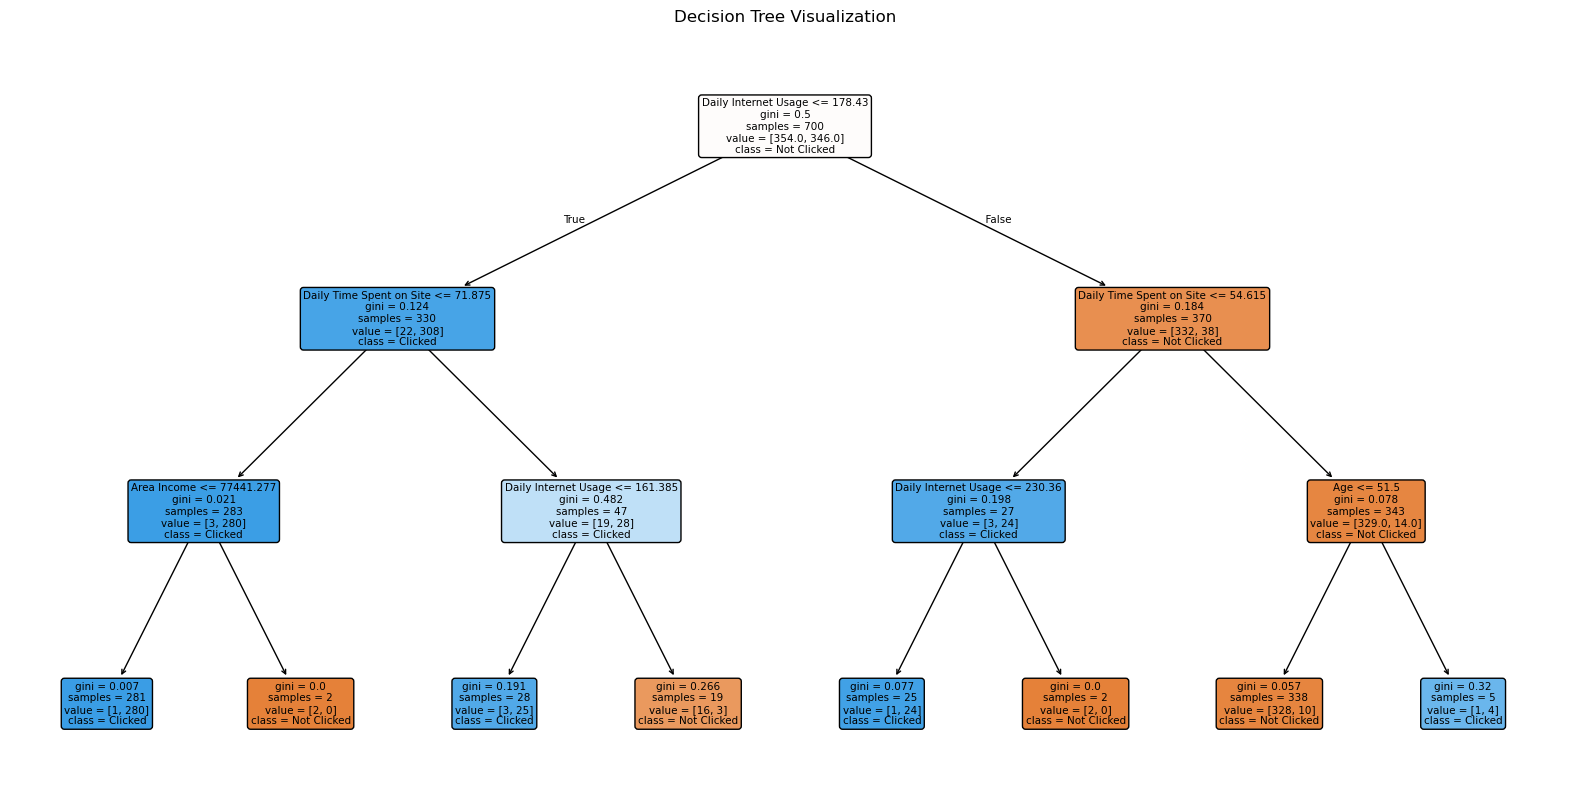

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# X, y 분리
X = df_model.drop('Clicked on Ad', axis=1)
y = df_model['Clicked on Ad']

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# 2. Decision Tree (시각화를 위해 깊이를 3으로 제한)
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_clf.fit(X_train, y_train)

# 트리 시각화
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, feature_names=X.columns, class_names=['Not Clicked', 'Clicked'], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

# 평가 및 예측

In [9]:
from sklearn.metrics import classification_report, roc_auc_score

# 예측 수행
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

y_pred_dt = dt_clf.predict(X_test)
y_prob_dt = dt_clf.predict_proba(X_test)[:, 1]

print("=== Logistic Regression 평가 ===")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_log):.4f}")

print("\n=== Decision Tree 평가 ===")
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")

=== Logistic Regression 평가 ===
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       146
           1       0.95      0.90      0.92       154

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300

ROC-AUC: 0.9745

=== Decision Tree 평가 ===
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       146
           1       0.95      0.91      0.93       154

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

ROC-AUC: 0.9356


# 비즈니스 인사이트 도출

<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

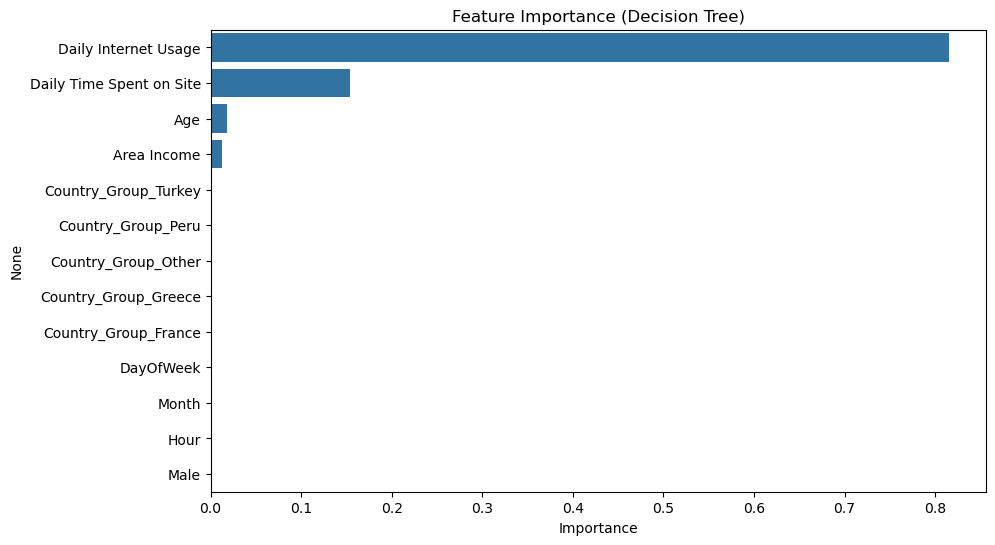

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. 데이터 불러오기 및 전처리
file_path = 'data/advertising.csv'
df = pd.read_csv(file_path)

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())

# 날짜 데이터 전처리
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

# 국가 그룹화 (상위 5개국 + 기타)
top5_countries = df['Country'].value_counts().head(5).index.tolist()
df['Country_Group'] = df['Country'].apply(lambda x: x if x in top5_countries else 'Other')

# 불필요 컬럼 제거 및 One-Hot Encoding
df_model = df.drop(['Ad Topic Line', 'City', 'Country', 'Timestamp'], axis=1)
df_model = pd.get_dummies(df_model, columns=['Country_Group'], drop_first=True)

# 2. 모델 학습
X = df_model.drop('Clicked on Ad', axis=1)
y = df_model['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_clf.fit(X_train, y_train)

# 3. 비즈니스 인사이트 시각화 (에러 해결 부분)
importances = dt_clf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns  # 현재 학습된 X의 컬럼명을 사용

# (1) 변수 중요도 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.title('Feature Importance (Decision Tree)')
plt.xlabel('Importance')
plt.ylabel